# 7-A2-A. 전국 가스 — 체인(5·6단계 예보입력) 검증 + bias보정

> PROJECT.md §4 7단계 / **검증목표 2**. 7-A2(실측 학습)를 **실제 서빙 체인**(5단계 수요예측 → 6단계 신재생예측 → 7단계 가스)으로 연결해 정직하게 재검증하고, 다른 모델과 **동일 지평(D+1/2/3/7/12)** 으로 평가한다.

**배경**: 기존 7-A2는 실측(real_demand_land, renew_gen_total_kr)으로 학습됐는데 서빙은 예보가 들어온다(train-serve 불일치).

**A안(시도)**: 서빙과 같은 예보 입력으로 재학습하면 분포가 정렬돼 나아질 것이다.
**A안 데이터 제약**: 진짜 forecast 기상은 2025-12부터만 존재 → train창(2022-24)은 **체인 백필(기후값 폴백)**로 생성(`training/build_chained_dataset.py`, 193,800행).

**결론(미리)**: A안은 **효과 없음(오히려 근소 악화)** → 기각. 진짜 지렛대는 **전역 bias보정**(val2025 ×0.965). 지평은 거의 평평(D+1≈D+12).


In [1]:
import pandas as pd, numpy as np, lightgbm as lgb, json, os, sqlite3
import matplotlib.pyplot as plt, matplotlib as mpl
from sklearn.metrics import mean_absolute_error, r2_score
mpl.rcParams['figure.dpi']=110; mpl.rcParams['axes.grid']=True
for _f in ['Malgun Gothic','NanumGothic','AppleGothic']:
    try: mpl.rcParams['font.family']=_f; break
    except Exception: pass
mpl.rcParams['axes.unicode_minus']=False
from pathlib import Path
FIG=Path('fig'); FIG.mkdir(exist_ok=True); TAB=Path('tab'); TAB.mkdir(exist_ok=True)
ROOT=os.path.normpath('../..'); SD=os.path.join(ROOT,'1. data_fetcher_and_db','second_dataset')
DB=os.path.join(ROOT,'1. data_fetcher_and_db','data','input_data_land.db')

df=pd.read_parquet('../training/chained_gas_dataset.parquet'); df['timestamp']=pd.to_datetime(df['timestamp'])
df['ym']=df['timestamp'].dt.to_period('M')
cap=pd.read_csv(os.path.join(SD,'kr_elec_capa.csv'),encoding='euc-kr').rename(columns={'기간':'period','지역':'region','LNG':'LNG_cap'})
cap=cap[cap['region']=='합계'].copy(); cap['ym']=pd.to_datetime(cap['period'],format='%b-%y').dt.to_period('M')
cap['LNG_cap']=pd.to_numeric(cap['LNG_cap'],errors='coerce'); lng=cap.dropna(subset=['LNG_cap']).set_index('ym')['LNG_cap'].sort_index()
full=pd.period_range(df.ym.min(),df.ym.max(),freq='M'); lng=lng.reindex(full).ffill()
df['LNG_cap']=df.ym.map(lng); df=df.dropna(subset=['LNG_cap','gen_gas_kr']); df=df[df.gen_gas_kr>0]
df['day_type']=pd.Categorical(df['day_type'],categories=['holiday','weekday','weekend'])
print('체인 데이터셋 split:', {k:int(v) for k,v in df.groupby('split').size().items()})
print('test 지평별:', {int(k):int(v) for k,v in df[df.split=="test"].groupby('horizon').size().items()})

mOld=lgb.Booster(model_file='lgbm_land_gas_util.txt')              # 실측 학습(현행)
mA  =lgb.Booster(model_file='lgbm_land_gas_util_chained.txt')      # A안(체인 학습)
FEATS=['real_demand_land','renew_gen_total_kr','hour','dow','month','doy','day_type']
CH=['est_demand','est_renew','hour','dow','month','doy','day_type']
def p_old_chain(g):  X=g[CH].copy(); X.columns=FEATS; return mOld.predict(X)*g.LNG_cap.values
def p_new_chain(g):  return mA.predict(g[CH].rename(columns=dict(zip(CH,FEATS))))*g.LNG_cap.values
def p_oracle(g):     return mOld.predict(g[FEATS])*g.LNG_cap.values
def mape(y,p): y,p=np.asarray(y,float),np.asarray(p,float); m=y>0; return float(np.mean(np.abs((y[m]-p[m])/y[m]))*100)
def bias(y,p): y,p=np.asarray(y,float),np.asarray(p,float); m=y>0; return float(np.mean((p[m]-y[m])/y[m])*100)


체인 데이터셋 split: {'test': 19010, 'train': 130920, 'val': 43800}
test 지평별: {1: 3802, 2: 3802, 3: 3802, 7: 3802, 12: 3802}


## 1. 보정계수 + 실측입력(ORACLE) 조인
- 전역 bias보정 = val2025 체인에서 `sum(actual)/sum(pred)`. 서빙도 동일계수 사용(`gas_serving_calib.json`).
- ORACLE = 구 7-A2 + **실측** 입력(도달 불가 상한). test 타깃시점 real_demand/renew를 historical에서 조인.

In [2]:
calib=json.load(open('gas_serving_calib.json',encoding='utf-8'))['bias_calib']
print('전역 bias보정계수 =',calib)
va=df[df.split=='val']; te=df[df.split=='test'].copy()
with sqlite3.connect(DB) as con:
    act=pd.read_sql('SELECT timestamp, real_demand_land, renew_gen_total_kr FROM historical',con,parse_dates=['timestamp']).set_index('timestamp')
te['real_demand_land']=act['real_demand_land'].reindex(te['timestamp']).values
te['renew_gen_total_kr']=act['renew_gen_total_kr'].reindex(te['timestamp']).values


전역 bias보정계수 = 0.96509


## 2. 지평별 정확도 (test 2026, 실측 gen_gas_kr 대조)
4가지 비교: ORACLE(상한) · 현행7-A2+체인 · A안 재학습 · **현행+bias보정(권장)**.

horizon  oracle  chain  Aretrain  calib  chain_bias  calib_bias  oracle_bias
    D+1   10.81  13.88     14.23  13.08        6.37        2.65         4.46
    D+2   10.81  13.93     14.33  13.01        6.91        3.18         4.46
    D+3   10.81  14.10     14.46  13.08        7.32        3.57         4.46
    D+7   10.81  14.16     14.57  13.10        7.91        4.14         4.46
   D+12   10.81  14.16     14.58  13.16        7.96        4.19         4.46


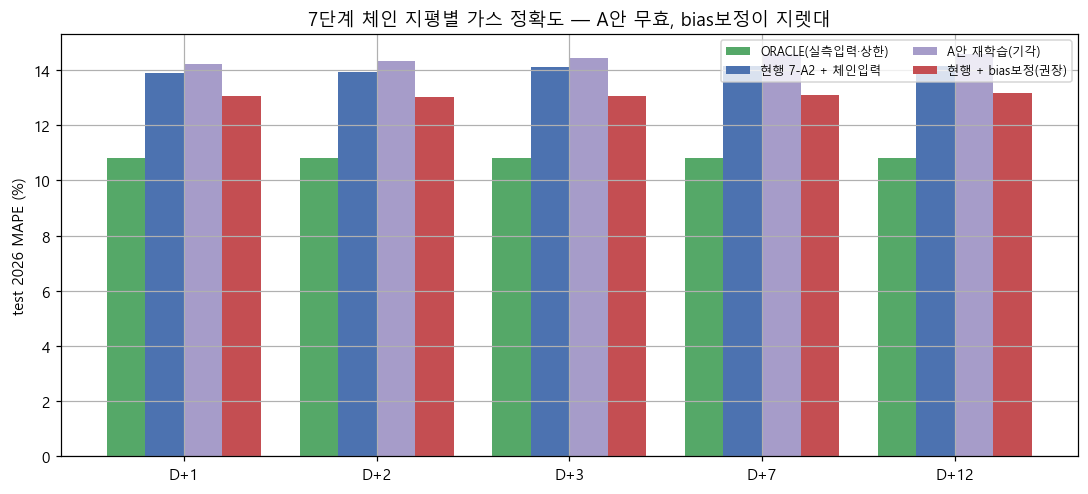

In [3]:
HZ=[1,2,3,7,12]; rows=[]
for n in HZ:
    g=te[te.horizon==n]; y=g.gen_gas_kr.values
    og=g.dropna(subset=['real_demand_land','renew_gen_total_kr'])
    pc=p_old_chain(g)
    rows.append(dict(horizon=f'D+{n}',
        oracle=mape(og.gen_gas_kr.values,p_oracle(og)),
        chain=mape(y,pc), Aretrain=mape(y,p_new_chain(g)),
        calib=mape(y,pc*calib),
        chain_bias=bias(y,pc), calib_bias=bias(y,pc*calib),
        oracle_bias=bias(og.gen_gas_kr.values,p_oracle(og))))
R=pd.DataFrame(rows); R.to_csv(TAB/'7a2a_horizon_metrics.csv',index=False)
print(R.round(2).to_string(index=False))

fig,ax=plt.subplots(figsize=(10,4.6)); x=np.arange(len(HZ)); w=0.2
ax.bar(x-1.5*w,R.oracle,w,label='ORACLE(실측입력·상한)',color='#55A868')
ax.bar(x-0.5*w,R.chain,w,label='현행 7-A2 + 체인입력',color='#4C72B0')
ax.bar(x+0.5*w,R.Aretrain,w,label='A안 재학습(기각)',color='#8172B3',alpha=.7)
ax.bar(x+1.5*w,R.calib,w,label='현행 + bias보정(권장)',color='#C44E52')
ax.set_xticks(x); ax.set_xticklabels(R.horizon); ax.set_ylabel('test 2026 MAPE (%)')
ax.set_title('7단계 체인 지평별 가스 정확도 — A안 무효, bias보정이 지렛대'); ax.legend(fontsize=8,ncol=2)
plt.tight_layout(); plt.savefig(FIG/'7a2a_horizon_mape.png'); plt.show()


## 3. bias 보정 효과 + 입력 bias(지평별)
- 체인 입력 자체의 bias(수요·신재생, 전 구간)와, 가스 예측 bias가 보정으로 어떻게 줄어드는지.

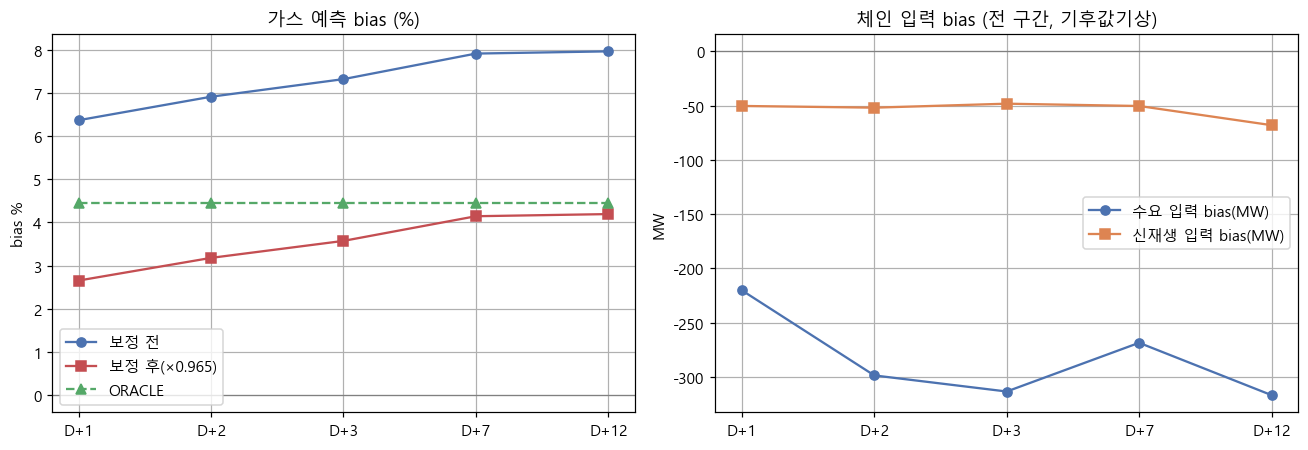

   h  demand  renew
 D+1  -220.0  -50.0
 D+2  -299.0  -52.0
 D+3  -314.0  -48.0
 D+7  -269.0  -50.0
D+12  -317.0  -68.0


In [4]:
fig,ax=plt.subplots(1,2,figsize=(12,4.2))
ax[0].axhline(0,color='gray',lw=.8)
ax[0].plot(R.horizon,R.chain_bias,'o-',label='보정 전',color='#4C72B0')
ax[0].plot(R.horizon,R.calib_bias,'s-',label='보정 후(×%.3f)'%calib,color='#C44E52')
ax[0].plot(R.horizon,R.oracle_bias,'^--',label='ORACLE',color='#55A868')
ax[0].set_title('가스 예측 bias (%)'); ax[0].set_ylabel('bias %'); ax[0].legend()
with sqlite3.connect(DB) as con:
    a2=pd.read_sql('SELECT timestamp, real_demand_land, renew_gen_total_kr FROM historical',con,parse_dates=['timestamp']).set_index('timestamp')
ib=[]
for n in HZ:
    g=df[df.horizon==n].join(a2,on='timestamp',rsuffix='_a')
    dd=g.dropna(subset=['real_demand_land'])
    ib.append(dict(h=f'D+{n}', demand=(dd.est_demand-dd.real_demand_land).mean(),
                   renew=(g.est_renew-g.renew_gen_total_kr).mean()))
IB=pd.DataFrame(ib)
ax[1].axhline(0,color='gray',lw=.8)
ax[1].plot(IB.h,IB.demand,'o-',label='수요 입력 bias(MW)',color='#4C72B0')
ax[1].plot(IB.h,IB.renew,'s-',label='신재생 입력 bias(MW)',color='#DD8452')
ax[1].set_title('체인 입력 bias (전 구간, 기후값기상)'); ax[1].set_ylabel('MW'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG/'7a2a_bias.png'); plt.show()
print(IB.round(0).to_string(index=False))


## 4. 예측 vs 실측 (D+1, 일별) — 보정 후

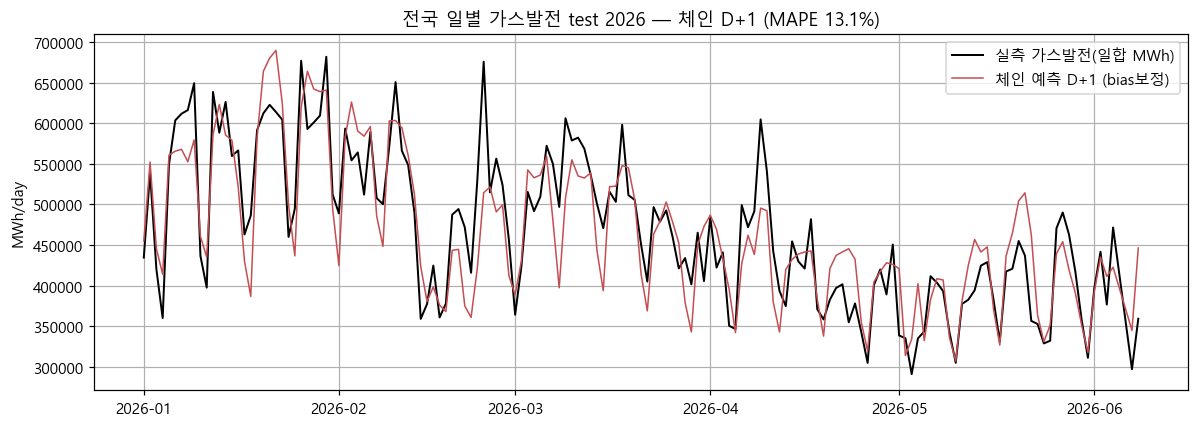

In [5]:
g=te[te.horizon==1].copy(); g['pred']=p_old_chain(g)*calib
dd=g.groupby(g.timestamp.dt.floor('D')).agg(act=('gen_gas_kr','sum'),pred=('pred','sum'),h=('gen_gas_kr','size')).reset_index()
dd=dd[dd.h==24]
fig,ax=plt.subplots(figsize=(11,4)); ax.plot(dd.timestamp,dd.act,'k-',lw=1.3,label='실측 가스발전(일합 MWh)')
ax.plot(dd.timestamp,dd.pred,color='#C44E52',lw=1,label='체인 예측 D+1 (bias보정)')
ax.set_title('전국 일별 가스발전 test 2026 — 체인 D+1 (MAPE %.1f%%)'%mape(g.gen_gas_kr,g.pred))
ax.set_ylabel('MWh/day'); ax.legend(); plt.tight_layout(); plt.savefig(FIG/'7a2a_pred_d1.png'); plt.show()


## 5. 보고서 산출

In [6]:
def row(n,c): return R[R.horizon==f'D+{n}'][c].iloc[0]
rep=f'''# 7-A2-A 보고서 — 전국 가스 체인 검증(5·6→7) + bias보정

## 한 줄 결론
서빙 체인(5단계 수요예측 → 6단계 신재생예측 → 7단계 가스)을 정직하게 평가하니 **test 2026 가스발전 MAPE ~13%**(ORACLE 상한 10.8%, 차이 +2.2%p는 예보 전파 비가역오차).
**A안(예보입력 재학습)은 효과 없어 기각**, 대신 **전역 bias보정 ×{calib}**로 ~14%→~13% 개선. **지평 거의 평평**(D+1≈D+12).

## 검증 구조
- 체인 데이터셋 `training/chained_gas_dataset.parquet`(193,800행). 수요=5-A2 지평별, 신재생=6단계 지평별, 기상=예보→(월,시)기후값 폴백, 타깃=실측 gen_gas_kr.
- 진짜 forecast 기상은 2025-12부터만 존재 → train창은 기후값기상 백필(서빙 하한 모드). test 2026 D+1~3은 실예보.
- 모델=기존 7-A2(util=gen_gas_kr/LNG_cap, ×용량복원). 동시점 회귀라 지평은 입력(5·6)에 내포.

## 지평별 정확도 (test 2026 MAPE %)
| 지평 | ORACLE(상한) | 현행+체인 | A안 재학습 | **현행+bias보정(권장)** |
|---|---|---|---|---|
| D+1  | {row(1,'oracle'):.2f} | {row(1,'chain'):.2f} | {row(1,'Aretrain'):.2f} | **{row(1,'calib'):.2f}** |
| D+2  | {row(2,'oracle'):.2f} | {row(2,'chain'):.2f} | {row(2,'Aretrain'):.2f} | **{row(2,'calib'):.2f}** |
| D+3  | {row(3,'oracle'):.2f} | {row(3,'chain'):.2f} | {row(3,'Aretrain'):.2f} | **{row(3,'calib'):.2f}** |
| D+7  | {row(7,'oracle'):.2f} | {row(7,'chain'):.2f} | {row(7,'Aretrain'):.2f} | **{row(7,'calib'):.2f}** |
| D+12 | {row(12,'oracle'):.2f} | {row(12,'chain'):.2f} | {row(12,'Aretrain'):.2f} | **{row(12,'calib'):.2f}** |

## 발견
1. **A안 기각(정직한 음성결과)**: 체인입력 재학습이 현행보다 0.3~0.4%p 나쁨. 체인입력 bias는 작고(수요 0.5%) 진짜오차는 분산(노이즈) → errors-in-variables 감쇠만 발생. train(기후값)↔test(실예보) 노이즈구조 차이로 정렬이득도 없음.
2. **지평 평평**: D+1({row(1,'chain'):.2f}%)≈D+12({row(12,'chain'):.2f}%). 가스 정확도는 지평이 아니라 상류 입력품질에 의존 → **D+12까지 D+1 수준** 가스예측 가능.
3. **bias보정이 지렛대**: val2025 전역계수 ×{calib} 하나로 전지평 bias +6~8%→+2.5~4.3%, MAPE −1%p. 지평별 계수도 동일범위→단일 전역계수 충분.
4. **남는 +2.2%p**(체인 vs ORACLE)는 수요·신재생 예보의 전파오차로 비가역(§5.4 정직성).

## 모델 피처 (재확인)
- 입력: real_demand_land(서빙=5단계 est_demand_land) + renew_gen_total_kr(서빙=6단계 est_market_renew_land, =solar_market+wind) + hour/dow/month/doy + day_type.
- 타깃: util=gen_gas_kr/LNG_cap → ×LNG_cap(월별 ffill) → ×bias_calib. 송출량(TON)=발전량(MWh)×0.1521(7-C).
- 제외: 기온·year·net_load(분해 내포)·HVDC·유류·타깃lag(누수).

## 서빙
- `serve_land_gas.py` : forecast.est_demand_land·est_market_renew_land 읽어 est_gas_gen_land·est_gas_sendout_ton_land UPSERT. 검증(D+1 백필 2026-02~05): 발전량 MAPE 13.07%·bias +3.2%.
- 보정계수·변환계수: `model/gas_serving_calib.json`.

## 산출물
- training/chained_gas_dataset.parquet, training/build_chained_dataset.py, training/retrain_7a2a.py
- model/lgbm_land_gas_util_chained.txt(A안, 미채택·기록), model/gas_serving_calib.json
- serve_land_gas.py
- fig/7a2a_horizon_mape.png, fig/7a2a_bias.png, fig/7a2a_pred_d1.png, tab/7a2a_horizon_metrics.csv
'''
open('REPORT_7-A2-A.md','w',encoding='utf-8').write(rep); print(rep)


# 7-A2-A 보고서 — 전국 가스 체인 검증(5·6→7) + bias보정

## 한 줄 결론
서빙 체인(5단계 수요예측 → 6단계 신재생예측 → 7단계 가스)을 정직하게 평가하니 **test 2026 가스발전 MAPE ~13%**(ORACLE 상한 10.8%, 차이 +2.2%p는 예보 전파 비가역오차).
**A안(예보입력 재학습)은 효과 없어 기각**, 대신 **전역 bias보정 ×0.96509**로 ~14%→~13% 개선. **지평 거의 평평**(D+1≈D+12).

## 검증 구조
- 체인 데이터셋 `training/chained_gas_dataset.parquet`(193,800행). 수요=5-A2 지평별, 신재생=6단계 지평별, 기상=예보→(월,시)기후값 폴백, 타깃=실측 gen_gas_kr.
- 진짜 forecast 기상은 2025-12부터만 존재 → train창은 기후값기상 백필(서빙 하한 모드). test 2026 D+1~3은 실예보.
- 모델=기존 7-A2(util=gen_gas_kr/LNG_cap, ×용량복원). 동시점 회귀라 지평은 입력(5·6)에 내포.

## 지평별 정확도 (test 2026 MAPE %)
| 지평 | ORACLE(상한) | 현행+체인 | A안 재학습 | **현행+bias보정(권장)** |
|---|---|---|---|---|
| D+1  | 10.81 | 13.88 | 14.23 | **13.08** |
| D+2  | 10.81 | 13.93 | 14.33 | **13.01** |
| D+3  | 10.81 | 14.10 | 14.46 | **13.08** |
| D+7  | 10.81 | 14.16 | 14.57 | **13.10** |
| D+12 | 10.81 | 14.16 | 14.58 | **13.16** |

## 발견
1. **A안 기각(정직한 음성결과)**: 체인입력 재학습이 현행보다 0.3~0.4%p 나쁨. 체인입력 bias는 작고(수요 0.5%) 진짜오차는 분산(노이즈) → errors-in-va